# GV Exercise – Iteration [5]

This notebook demonstrates the exact same data preparation, training, and inference flow as the production code by importing the reusable modules under `src/`.

It intentionally avoids ad-hoc pandas logic so experiments stay aligned with the CLI scripts and MLflow-tracked runs.

In [1]:
%pip install seaborn
%pip install optuna
%pip install shap

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Phase 1: Environment Setup

Bootstrap project imports and configuration. This sets up the shared imports, config, and logging so experiments match CLI runs.

In [2]:
import sys
import json
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
import xgboost as xgb

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.common import load_config
from src.common.logging import init_logging
from src.models.io import load_model_bundle
from src.predict.inference import predict_batch
from src.models.training import train_ranker
from src.models.metrics import calculate_relevance_grade
from src.features.types import FeatureMatrix, FeatureMetadata
from src.features.pipeline import FeaturePipeline, _to_bool_series
from src.features.feature_factory import (
    build_post_split_feature_frames,
    compute_founder_experience_features,
)

cfg = load_config()
init_logging(cfg.logging)
cfg.tracking.experiment_name = 'founder_ranking_v5'


## Phase 2: Data Loading

Load the curated training tables and target labels using the shared loaders so the notebook matches the CLI data flow.


### 2.1 Data Loading & Cleaning

Load the raw training data and target labels from the configured data directories.

In [3]:
from src.data.loaders import load_raw, clean, load_targets
raw_training = load_raw(cfg.data, dataset='training')
clean_training = clean(raw_training)
raw_ranking = load_raw(cfg.data, dataset='ranking')
clean_ranking = clean(raw_ranking)
target_df = load_targets(cfg.data)
print('Training:', { 'experience': clean_training.experience.shape, 'education': clean_training.education.shape, 'company_info': clean_training.company_info.shape })
print('Ranking:', { 'experience': clean_ranking.experience.shape, 'education': clean_ranking.education.shape, 'company_info': clean_ranking.company_info.shape })
print('Targets:', target_df.shape, list(target_df.columns))


Training: {'experience': (54616, 12), 'education': (4772, 3), 'company_info': (13898, 3)}
Ranking: {'experience': (1583, 12), 'education': (120, 3), 'company_info': (456, 3)}
Targets: (2000, 4) ['company_id', 'industry', 'company_founded', 'multiple']


## Phase 3: Pre-Split – Build Founder Matrix

Define one label company per founder (best exit) and build the pre-split founder-level feature matrix as of that label_company_founded_year. This snapshot is what we will later split into train/val/test.


In [4]:
# Section 2: Label companies and build the pre-split founder matrix.

def build_founder_label_table(clean_training, target_df):
    """Return one row per founder using the best-exit company as label."""

    experience = clean_training.experience.copy()
    if "is_founder" not in experience.columns:
        raise ValueError("Expected 'is_founder' column in training experience data")

    experience["is_founder"] = _to_bool_series(experience["is_founder"])
    founder_rows = experience[experience["is_founder"] == True].copy()  # noqa: E712
    founder_rows = founder_rows[founder_rows["company_id"].notna()].copy()

    targets = target_df[["company_id", "company_founded", "multiple", "industry"]].copy()
    founder_rows["company_id"] = founder_rows["company_id"].astype(str)
    targets["company_id"] = targets["company_id"].astype(str)

    labeled = founder_rows.merge(targets, on="company_id", how="inner")
    if labeled.empty:
        raise ValueError("No founder experiences with labels found in target data")

    # Choose the company with the highest multiple per founder;
    # break ties by taking the earliest order.
    labeled = labeled.sort_values(["person_id", "multiple", "order"], ascending=[True, False, True])
    best = labeled.groupby("person_id", as_index=False).head(1)

    label_table = best[["person_id", "company_id", "multiple", "company_founded", "industry"]].copy()
    label_table.rename(
        columns={
            "company_id": "label_company_id",
            "multiple": "label_max_founder_multiple",
            "company_founded": "label_company_founded_year",
            "industry": "label_company_industry",
        },
        inplace=True,
    )
    return label_table


# Build base founder feature matrix (one row per founder) using FeaturePipeline.
feature_pipeline = FeaturePipeline(cfg.features)
founder_fm = feature_pipeline.build_matrix(clean_training)
founder_features = founder_fm.frame.copy()

# Build per-founder label table using the best-exit company.
founder_labels = build_founder_label_table(clean_training, target_df)

# Join to get the initial founder matrix (pre-split, one row per founder).
founder_matrix = founder_features.merge(founder_labels, on="person_id", how="inner")

# Override company metadata to reflect the label company snapshot.
founder_matrix["company_id"] = founder_matrix["label_company_id"].astype(str)
founder_matrix["industry"] = (
    founder_matrix["label_company_industry"]
    .fillna("Other")
    .replace({"unknown": "Other"})
)
founder_matrix["company_founded"] = pd.to_numeric(
    founder_matrix["label_company_founded_year"], errors="coerce"
)

# Re-compute performance as the performance of the label company.
perf_lookup = clean_training.company_info.set_index("company_id")["performance"].to_dict()
founder_matrix["performance"] = founder_matrix["company_id"].map(perf_lookup)

# Drop founders with unknown label_company_founded_year so temporal splits are well-defined.
founder_matrix = founder_matrix.dropna(subset=["company_founded"]).reset_index(drop=True)

# Attach raw max multiple label and derived relevance grade (cfg.features.target_column).
founder_matrix["label_max_founder_multiple"] = (
    founder_matrix["label_max_founder_multiple"].astype(float)
)
founder_matrix[cfg.features.target_column] = founder_matrix["label_max_founder_multiple"].apply(
    calculate_relevance_grade
)

print(
    f"Prepared founder matrix (pre-split) with {len(founder_matrix)} rows and {len(founder_matrix.columns)} columns",
)

# This is the dataset that will be temporally split by industry and label_company_founded_year.
training_df = founder_matrix


Prepared founder matrix (pre-split) with 4766 rows and 13 columns


In [5]:
# Define feature columns from config
# feature_columns = [col for col in cfg.features.selected_columns if col != 'performance']
feature_columns = cfg.features.selected_columns

## Phase 4: Split – Temporal Train/Val/Test

Perform per-industry temporal splitting by label_company_founded_year so older founders land in train and newer founders in validation and test.


In [6]:
def temporal_train_val_test_split_by_industry(
    df,
    feature_cols,
    target_col,
    train_ratio: float = 0.7,
    val_ratio: float = 0.15,
):
    """Per-industry temporal Train/Val/Test split on company_founded."""

    df = df.copy()
    df = df.dropna(subset=["company_founded"])
    df["industry"] = df["industry"].fillna("Other")

    train_dfs = []
    val_dfs = []
    test_dfs = []
    train_groups = []
    val_groups = []
    test_groups = []
    industry_names = []

    for industry, cohort in df.groupby("industry", sort=False):
        cohort = cohort.sort_values(["company_founded", "company_id", "person_id"])
        n = len(cohort)
        if n < 3:
            train_dfs.append(cohort)
            val_dfs.append(cohort.iloc[0:0])
            test_dfs.append(cohort.iloc[0:0])
            train_groups.append(n)
            val_groups.append(0)
            test_groups.append(0)
            industry_names.append(industry)
            continue

        n_train = max(1, int(n * train_ratio))
        n_val = max(1, int(n * val_ratio))
        if n_train + n_val >= n:
            n_train = max(1, n - 2)
            n_val = 1
        n_test = n - n_train - n_val

        train_cohort = cohort.iloc[:n_train]
        val_cohort = cohort.iloc[n_train:n_train + n_val]
        test_cohort = cohort.iloc[n_train + n_val:]

        train_dfs.append(train_cohort)
        val_dfs.append(val_cohort)
        test_dfs.append(test_cohort)
        industry_names.append(industry)
        train_groups.append(len(train_cohort))
        val_groups.append(len(val_cohort))
        test_groups.append(len(test_cohort))

    train_df = pd.concat(train_dfs, ignore_index=True)
    val_df = pd.concat(val_dfs, ignore_index=True)
    test_df = pd.concat(test_dfs, ignore_index=True)

    return (
        train_df,
        val_df,
        test_df,
        train_groups,
        val_groups,
        test_groups,
        industry_names,
    )

(
    train_df,
    val_df,
    test_df,
    train_groups,
    val_groups,
    test_groups,
    industry_names,
) = temporal_train_val_test_split_by_industry(
    df=training_df,
    feature_cols=feature_columns,
    target_col=cfg.features.target_column,
    train_ratio=0.7,
    val_ratio=0.15,
)

print("\n=== Split Summary (Train / Val / Test) ===")
print(f"Total samples: {len(training_df)}")
print(f"Train samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Number of industry cohorts: {len(industry_names)}")

for idx, industry in enumerate(industry_names):
    train_count = train_groups[idx]
    val_count = val_groups[idx]
    test_count = test_groups[idx]
    total = train_count + val_count + test_count

    train_labels = train_df[train_df["industry"] == industry][cfg.features.target_column]
    val_labels = val_df[val_df["industry"] == industry][cfg.features.target_column]
    test_labels = test_df[test_df["industry"] == industry][cfg.features.target_column]

    print(f"\n{industry}:")
    print(
        f"  Total: {total} | Train: {train_count} ({train_count/total*100:.1f}%)"
        f" | Val: {val_count} ({val_count/total*100:.1f}%)"
        f" | Test: {test_count} ({test_count/total*100:.1f}%)"
    )
    print(f"  Train labels: {dict(sorted(train_labels.value_counts().to_dict().items()))}")
    print(f"  Val labels: {dict(sorted(val_labels.value_counts().to_dict().items()))}")
    print(f"  Test labels: {dict(sorted(test_labels.value_counts().to_dict().items()))}")

print(f"\nTraining rows: {len(training_df)} | Feature columns: {len(feature_columns)}")
train_df.head()




=== Split Summary (Train / Val / Test) ===
Total samples: 4766
Train samples: 3335
Validation samples: 714
Test samples: 717
Number of industry cohorts: 3

Information Technology:
  Total: 2935 | Train: 2054 (70.0%) | Val: 440 (15.0%) | Test: 441 (15.0%)
  Train labels: {0: 1087, 1: 394, 2: 283, 3: 192, 4: 76, 5: 12, 6: 10}
  Val labels: {0: 375, 1: 27, 2: 17, 3: 17, 4: 4}
  Test labels: {0: 426, 1: 7, 2: 5, 5: 3}

Healthcare and Biotech:
  Total: 1022 | Train: 715 (70.0%) | Val: 153 (15.0%) | Test: 154 (15.1%)
  Train labels: {0: 301, 1: 211, 2: 106, 3: 74, 4: 16, 6: 7}
  Val labels: {0: 110, 1: 26, 2: 8, 3: 7, 4: 2}
  Test labels: {0: 138, 1: 12, 2: 4}

Other:
  Total: 809 | Train: 566 (70.0%) | Val: 121 (15.0%) | Test: 122 (15.1%)
  Train labels: {0: 370, 1: 61, 2: 47, 3: 26, 4: 16, 5: 38, 6: 5, 7: 3}
  Val labels: {0: 110, 1: 2, 2: 3, 3: 3, 5: 3}
  Test labels: {0: 122}

Training rows: 4766 | Feature columns: 3


,person_id,company_id,performance,education_tier,education_level_score,industry,is_founder_of_target,label_company_id,label_max_founder_multiple,label_company_founded_year,label_company_industry,company_founded,label
0,SAZwBg4JABobMgcPHywABA==,SBVwFw4GEw0dCgA=,2.804569,5.0,4.0,Information Technology,True,SBVwFw4GEw0dCgA=,4.193972,1980.0,Information Technology,1980.0,1
1,SAZwHAAZDDcCCAsIGA==,SBVwFw4GEw0dCgA=,2.804569,2.0,5.0,Information Technology,True,SBVwFw4GEw0dCgA=,4.193972,1980.0,Information Technology,1980.0,1
2,SAZwAA4GOgoOHxAEHg==,SBVwGQgIFwcYDBMCKSsRAgMLBwMCAh4pNhoC,9.075158,1.0,2.0,Information Technology,True,SBVwGQgIFwcYDBMCKSsRAgMLBwMCAh4pNhoC,0.289271,1982.0,Information Technology,1982.0,0
3,SAZwAAkECAkcMgcGBCoXCTRVWFo=,SBVwGQgIFwcYDBMCKSsRAgMLBwMCAh4pNhoC,9.075158,3.0,4.0,Information Technology,True,SBVwGQgIFwcYDBMCKSsRAgMLBwMCAh4pNhoC,0.289271,1982.0,Information Technology,1982.0,0
4,SAZwGQAfETcbDBwLGS0rUVpQ,SBVwABQfFhEc,0.780752,3.0,5.0,Information Technology,True,SBVwABQfFhEc,15.862562,1983.0,Information Technology,1983.0,2


## Phase 5: Post-Split Feature Engineering

On top of the temporally split founder matrix, build post-split features (performance aggregates, network, and team size) using only history up to each founder's label_company_founded_year and fit them on train before applying to val/test.


In [7]:
# Build post-split, time-respecting features (performance, network, team, experience).

# Lookup from person_id -> label_company_founded_year for time cut-offs.
label_year_lookup = (
    training_df.set_index("person_id")["label_company_founded_year"]
    .astype(int)
    .to_dict()
)

# Prepare shared tables for the reusable post-split feature builder.
experience_all = clean_training.experience.copy()
experience_all["is_founder"] = _to_bool_series(experience_all["is_founder"])
founder_history_all = experience_all[experience_all["is_founder"] == True].copy()  # noqa: E712

all_founder_ids = training_df["person_id"].dropna().astype(str).unique().tolist()
company_year_lookup = (
    training_df.set_index("company_id")["label_company_founded_year"]
    .astype(int)
    .to_dict()
)

exp_features = compute_founder_experience_features(
    experience=experience_all,
    cut_off_years=label_year_lookup,
    current_year=cfg.features.current_year,
)

perf_agg, network_df, team_df = build_post_split_feature_frames(
    experience=experience_all,
    founder_history=founder_history_all,
    education=clean_training.education.copy(),
    company_info=clean_training.company_info.copy(),
    founder_ids=all_founder_ids,
    current_year=cfg.features.current_year,
    founder_cutoff_years=label_year_lookup,
    company_cutoff_years=company_year_lookup,
)

# Join post-split features into each split (by person_id / company_id).
def _enrich_with_post_split_features(frame: pd.DataFrame) -> pd.DataFrame:
    enriched = frame.merge(exp_features, on="person_id", how="left")
    enriched = enriched.merge(perf_agg, on="person_id", how="left")
    enriched = enriched.merge(network_df, on="person_id", how="left")
    enriched = enriched.merge(team_df, on="company_id", how="left")
    return enriched

train_df = _enrich_with_post_split_features(train_df)
val_df = _enrich_with_post_split_features(val_df)
test_df = _enrich_with_post_split_features(test_df)

# Final feature columns include pre-split local features and post-split aggregates.
feature_columns = list(
    dict.fromkeys(
        feature_columns
        + [
            "founder_has_perf",
            "founder_perf_mean",
            "founder_perf_max",
            # "founder_perf_last",
            "network_quality_1st",
            "network_size_1st",
            "team_size",
            "n_c_suite_roles",
            "n_employee_roles",
            "n_executive_roles",
            "n_founder_roles",
            "n_board_roles",
            "n_experience_roles",
            "total_experience_years",
        ]
    ).keys()
)

X_train = train_df[feature_columns]
y_train = train_df[cfg.features.target_column]
X_val = val_df[feature_columns]
y_val = val_df[cfg.features.target_column]
X_test = test_df[feature_columns]
y_test = test_df[cfg.features.target_column]

print(
    f"Training rows (with post-split features): {len(training_df)} | Feature columns: {len(feature_columns)}"
)


/Users/yugu/Desktop/gehirn/gv_case_study/xgboost/src/features/feature_factory.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  work[col] = work[col].fillna(False).astype(int)
/Users/yugu/Desktop/gehirn/gv_case_study/xgboost/src/features/feature_factory.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  work[col] = work[col].fillna(False).astype(int)


Training rows (with post-split features): 4766 | Feature columns: 16


## Phase 6: Model Training & Persistence

Train the XGBoost ranker on the temporally split founder matrix and persist the trained bundle (estimator + feature metadata) in the same structure used by the CLI.


In [8]:
params = cfg.model.hyperparameters.copy()

# Use the validation split as the eval set passed into train_ranker;
# the test split is held out and evaluated separately.
ranker, metrics = train_ranker(
    X_train=X_train,
    y_train=y_train,
    X_test=X_val,
    y_test=y_val,
    train_groups=train_groups,
    test_groups=val_groups,
    industry_names=industry_names,
    params=params,
    tracking_uri=cfg.tracking.uri,
    experiment_name=cfg.tracking.experiment_name,
    run_name=datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
)

# Save train and validation predictions (all columns + label + predicted score) for this experiment.
train_pred_df = train_df.copy()
train_pred_df["predicted_score"] = ranker.predict(X_train)
val_pred_df = val_df.copy()
val_pred_df["predicted_score"] = ranker.predict(X_val)

experiment_dir = cfg.model.artifact_dir / cfg.tracking.experiment_name
experiment_dir.mkdir(parents=True, exist_ok=True)
train_pred_path = experiment_dir / "train_predictions.csv"
val_pred_path = experiment_dir / "val_predictions.csv"
train_pred_df.to_csv(train_pred_path, index=False)
val_pred_df.to_csv(val_pred_path, index=False)
print(f"Saved train/val predictions to {experiment_dir}")


/Users/yugu/Desktop/gehirn/gv_case_study/.venv/lib/python3.13/site-packages/mlflow/tracking/_tracking_service/utils.py:140: FutureWarning: Filesystem tracking backend (e.g., './mlruns') is deprecated. Please switch to a database backend (e.g., 'sqlite:///mlflow.db'). For feedback, see: https://github.com/mlflow/mlflow/issues/18534
  return FileStore(store_uri, store_uri)
2025/11/25 14:46:43 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2025/11/25 14:46:43 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.
2025/11/25 14:46:44 INFO mlflow.xgboost._autolog: Identified one or more metrics with names containing the invalid character `@`. These metric names have been sanitized by replacing `@` with `_at_`, as follows: ndcg_at_20
2025/11/25 14:46:44 INFO mlflow.xgboost._autolog: Identified one or more metrics with names containing the invalid character `@`. These metric names have bee


=== Per-Industry NDCG@20 and RECALL@20 Scores ===
Information Technology:
  Train: ndcg=0.7942, recall=0.1735 | Val: ndcg=0.5226, recall=0.2500
Healthcare and Biotech:
  Train: ndcg=0.4903, recall=0.4783 | Val: ndcg=0.3147, recall=0.0000
Other:
  Train: ndcg=0.5647, recall=0.3226 | Val: ndcg=0.6188, recall=0.6667

=== Mean NDCG@20 ===
Train ndcg@20: 0.6164
Test ndcg@20: 0.4854

=== Mean RECALL@20 ===
Train recall@20: 0.3248
Test recall@20: 0.3056
Saved train/val predictions to /Users/yugu/Desktop/gehirn/gv_case_study/xgboost/mlruns/models/founder_ranking_v5


In [9]:
# held_out_test
from src.models.metrics import calculate_mean_ndcg, calculate_mean_recall

test_scores = ranker.predict(X_test)
test_ndcg = calculate_mean_ndcg(
    labels=y_test.tolist(),
    scores=test_scores.tolist(),
    groups=test_groups,
    eval_metric=cfg.model.hyperparameters["eval_metric"],
)
test_recall = calculate_mean_recall(
    labels=y_test.tolist(),
    scores=test_scores.tolist(),
    groups=test_groups,
    eval_metric=cfg.model.hyperparameters["eval_metric"],
)
print("Held-out Test ndcg@20:", test_ndcg)
print("Held-out Test recall@20:", test_recall)

# Save test predictions (all columns + label + predicted score) for this experiment.
test_pred_df = test_df.copy()
test_pred_df["predicted_score"] = test_scores
experiment_dir = cfg.model.artifact_dir / cfg.tracking.experiment_name
experiment_dir.mkdir(parents=True, exist_ok=True)
test_pred_path = experiment_dir / "test_predictions.csv"
test_pred_df.to_csv(test_pred_path, index=False)
print(f"Saved test predictions to {experiment_dir}")


2025/11/25 14:46:49 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/Users/yugu/Desktop/gehirn/gv_case_study/.venv/lib/python3.13/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."


Held-out Test ndcg@20: 0.294179890142154
Held-out Test recall@20: 0.3333333333333333
Saved test predictions to /Users/yugu/Desktop/gehirn/gv_case_study/xgboost/mlruns/models/founder_ranking_v5


### 6.1 Persist Trained Bundle

Save the trained model and auxiliary metadata (like feature columns and outcome lookups) to disk so inference and SHAP analysis can reload the exact bundle.


In [10]:
# Persist the trained bundle locally to mirror CLI artifact structure
run_name = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
# Organize notebook runs under timestamped folders for traceability
run_dir = cfg.model.artifact_dir / "notebook_runs" / run_name
run_dir.mkdir(parents=True, exist_ok=True)

model_path = run_dir / "ranker.json"
artifacts_path = run_dir / "artifacts.json"
# Save the booster for reuse in inference cells
ranker.save_model(model_path)

# Bundle auxiliary metadata used during inference
artifacts = {
    "feature_columns": feature_columns,
}
# Persist metadata next to the model bundle
artifacts_path.write_text(json.dumps(artifacts, indent=2))

run_dir


PosixPath('/Users/yugu/Desktop/gehirn/gv_case_study/xgboost/mlruns/models/notebook_runs/20251125T194649Z')

> **Why does `artifacts.json` store company outcomes?**
>
> The mapping is used to label past companies when computing founder experience features (e.g., counting prior 10x exits). Each founder example still receives an individual label during training (`relevance_grade`) and we score founders after training, but we need company-level multiples to quantify their historical track records.

## Phase 7: Inference

Load the freshly written bundle and score current founders. This demonstrates how to reload the saved model and use it to generate predictions for new data.

**Industry-aware ranking:**
The XGBoost ranker is trained with industry-level groups, so we compute ranks *within each industry* rather than as a single global list. The `rank` column should therefore be interpreted as an industry-specific leaderboard.

**Note on SHAP Explanations:**
We enable SHAP value calculation (`shap_top_n=3`) to provide local interpretability for each prediction. The `explanation` column in the output dataframe lists the top 3 features contributing to the score for each founder.

In [11]:
# Reload the saved bundle and score the latest founders
bundle = load_model_bundle(
    registry_cfg=cfg.registry,
    project_root=cfg.project.root,
    model_root=run_dir,
)

# Pull current founders and clean them the same way as training data
raw_ranking = load_raw(cfg.data, dataset="ranking")
clean_ranking = clean(raw_ranking)

# Build the base founder matrix for ranking founders using the same feature config
feature_pipeline = FeaturePipeline(cfg.features)
base_fm = feature_pipeline.build_matrix(clean_ranking)
base_frame = base_fm.frame.copy()

# Build post-snapshot aggregates for inference (performance, network, team)
exp_rank = clean_ranking.experience.copy()
exp_rank["is_founder"] = _to_bool_series(exp_rank["is_founder"])
founder_history_rank = exp_rank[exp_rank["is_founder"] == True].copy()  # noqa: E712
founder_ids_rank = base_frame["person_id"].astype(str).unique().tolist()

exp_features_rank = compute_founder_experience_features(
    experience=exp_rank,
    cut_off_years=None,
    current_year=cfg.features.current_year,
)

perf_agg_rank, network_df_rank, team_df_rank = build_post_split_feature_frames(
    experience=exp_rank,
    founder_history=founder_history_rank,
    education=clean_ranking.education.copy(),
    company_info=clean_ranking.company_info.copy(),
    founder_ids=founder_ids_rank,
    current_year=cfg.features.current_year,
)

ranking_frame = base_frame.merge(exp_features_rank, on="person_id", how="left")
ranking_frame = ranking_frame.merge(perf_agg_rank, on="person_id", how="left")
ranking_frame = ranking_frame.merge(network_df_rank, on="person_id", how="left")
ranking_frame = ranking_frame.merge(team_df_rank, on="company_id", how="left")

ranking_features = FeatureMatrix(
    frame=ranking_frame,
    metadata=FeatureMetadata(
        feature_columns=bundle.feature_columns,
        entity_column="person_id",
    ),
)

# Run batch prediction with SHAP explanations enabled (top 3 features)
predictions = predict_batch(bundle, ranking_features, shap_top_n=3)
print(predictions.head())

# Write final ranked founders file for submission.
experiments_dir = cfg.project.root / "experiments"
experiments_dir.mkdir(parents=True, exist_ok=True)
ranked_path = experiments_dir / "ranked_founders.csv"
predictions.to_csv(ranked_path, index=False)
print(f"Saved ranked founders to {ranked_path}")


/Users/yugu/Desktop/gehirn/gv_case_study/xgboost/src/features/feature_factory.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  work[col] = work[col].fillna(False).astype(int)
/Users/yugu/Desktop/gehirn/gv_case_study/xgboost/src/features/feature_factory.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  work[col] = work[col].fillna(False).astype(int)


                         founder_id                industry     score  rank  \
0  SAZwAAgMFwkBMgsGDD4GGAoLNx8FOgM=  Information Technology  0.375848     1   
1      SAZwFRMGAAYwHgQAHj4ABAcMCQE=  Information Technology  0.082479     2   
2      SAZwBwQZAg0WMggGBDQbEhIEBg==  Information Technology -0.003702     3   
3          SAZwGQAZDjcHBAsDGz4GEgM=  Information Technology -0.597027     4   
4          SAZwBAQZFxEwBQQLEjoaAxI=  Information Technology -0.636216     5   

                                         explanation  
0  Top factors: performance (-0.54), founder_perf...  
1  Top factors: performance (-0.62), education_ti...  
2  Top factors: performance (-0.63), network_qual...  
3  Top factors: performance (-1.26), education_ti...  
4  Top factors: performance (-1.22), education_ti...  
Saved ranked founders to /Users/yugu/Desktop/gehirn/gv_case_study/xgboost/experiments/ranked_founders.csv


## Phase 8: SHAP Explanation

Visualize global feature importance and local impact using SHAP (SHapley Additive exPlanations) to understand what drives the model's ranking decisions.


SHAP Summary Plot (Global Feature Importance):


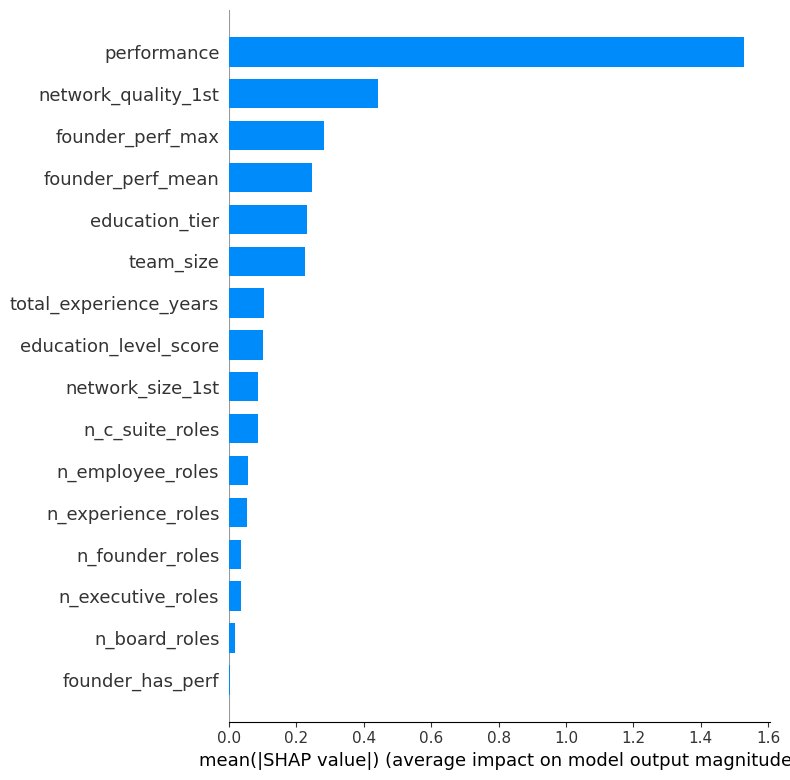

SHAP Beeswarm Plot (Feature Impact Direction):


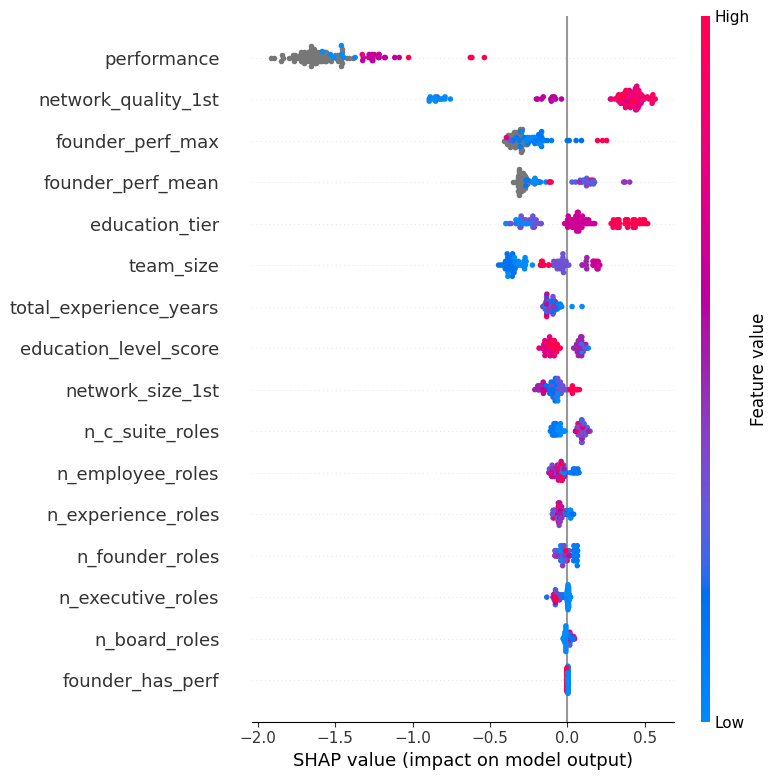


SHAP summary for industry: Healthcare and Biotech (n=13)


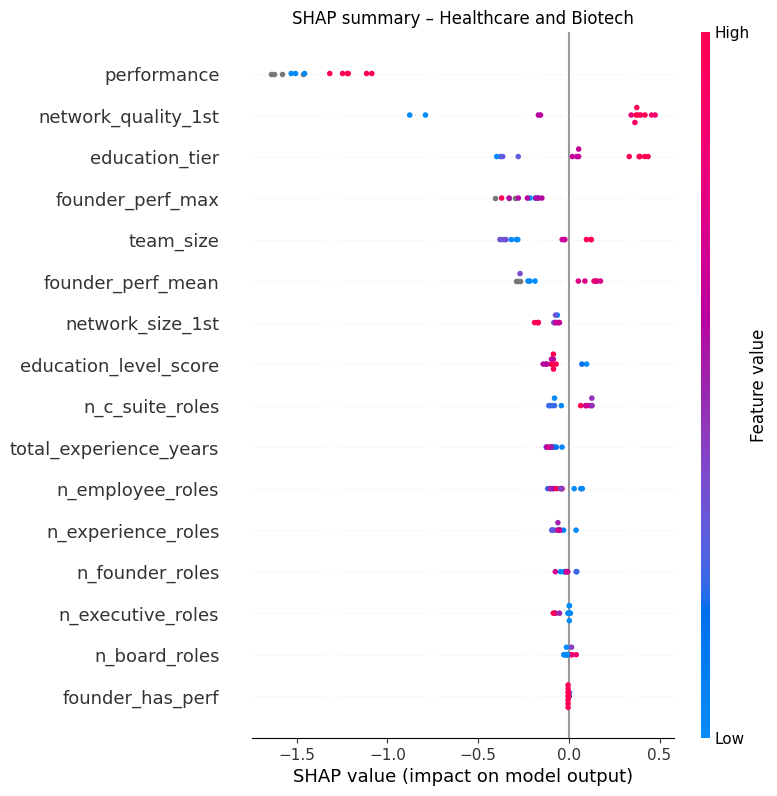


SHAP summary for industry: Information Technology (n=75)


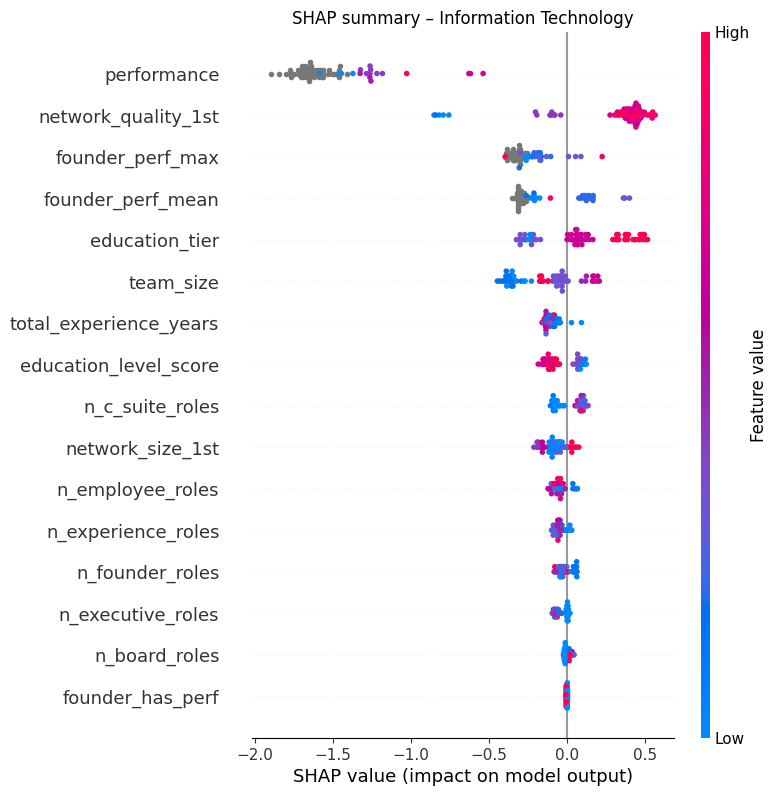


SHAP summary for industry: Other (n=27)


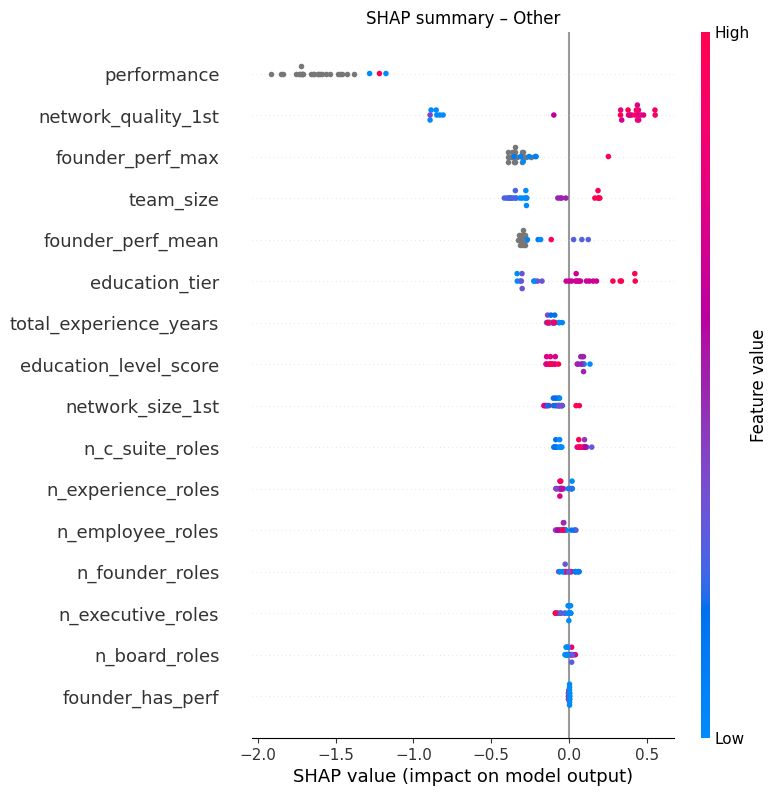

In [12]:
import shap
import matplotlib.pyplot as plt

# Use the estimator from the loaded bundle
model = bundle.estimator

# Select only the feature columns for SHAP calculation
X_ranking = ranking_features.select_columns(bundle.feature_columns)

# Initialize the explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_ranking)

# Handle case where shap_values might be a list (for some XGBoost objectives)
if isinstance(shap_values, list):
    shap_values = shap_values[0]

print("SHAP Summary Plot (Global Feature Importance):")
shap.summary_plot(shap_values, X_ranking, plot_type="bar")
plt.show()

print("SHAP Beeswarm Plot (Feature Impact Direction):")
shap.summary_plot(shap_values, X_ranking)
plt.show()

# Per-industry SHAP summary (excluding unknown)
industry_series = ranking_features.frame["industry"]
valid_industries = [
    value
    for value in sorted(industry_series.dropna().unique())
    if isinstance(value, str) and value and value.lower() != "unknown"
]

for industry in valid_industries:
    mask = industry_series == industry
    print(f"\nSHAP summary for industry: {industry} (n={mask.sum()})")
    shap.summary_plot(
        shap_values[mask.values],
        X_ranking[mask.values],
        show=False,
    )
    plt.title(f"SHAP summary – {industry}")
    plt.show()
